In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset, random_split
import tifffile as tiff
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from PIL import Image
from tqdm import tqdm
from torchvision import transforms
from skimage import io
import sys
# from umap import UMAP
import joblib
import pandas as pd

# Load Data
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [2]:
# Current working directory (notebook location)
script_dir = os.getcwd()

# Go up TWO levels for core and utils functions
parent_dir = os.path.dirname(os.path.dirname(script_dir))

# Add to Python path
sys.path.append(parent_dir)

from core.autoencoders import AE, train_ae
from core.dataset import TIFFDataset
from utils.feature_analysis import UMAP_train, patch_csv_to_AE_latent, patch_2_normed_tensor,histmatch_patch_2_normed_tensor,data_to_latents, kmeans_latents,latent_to_umap,UMAP_train,DBSCAN_cluster,kmeans_cluster,dataloader_model_latents,add_features_to_latent
from utils.plotting_utils import umap_2Dplot, cluster_2Dplot


In [3]:
root_dir = '/mnt/d/lding/CLS_GitHub/fa_patch_AE_clustering/results/pax_wholecell_correctloader_ch1_ps32_latdim_8_20251203_2323'
output_rootdir = os.path.join(root_dir,'pPax_data_results')
os.makedirs(output_rootdir,exist_ok=True)
czi_base = '/mnt/d/lding/FA/data/FA_ML_Annabel_20250217/pPax_data/eGFP-Zyxin488_Phalloidin405_pPaxy118rb647_PaxM568'
analysis_base = '/mnt/d/lding/FA/analysis_results/FA_ML_Annabel_20250217/0311pPax_data/eGFP-Zyxin488_Phalloidin405_pPaxy118rb647_PaxM568/'

ae_path = os.path.join(root_dir,'ae_model_ep9999.pt')
ae = torch.load(ae_path, map_location=device, weights_only=False)
ae = ae.to(device)
ae.eval()

AE(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.01)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): LeakyReLU(negative_slope=0.01)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): LeakyReLU(negative_slope=0.01)
    (9): Flatten(start_dim=1, end_dim=-1)
  )
  (encoder_fc): Sequential(
    (0): Linear(in_features=2048, out_features=1024, bias=True)
    (1): LeakyReLU(negative_slope=0.01)
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=1024, out_features=8, bias=True)
  )
  (decoder_fc): Sequential(
    (0): Linear(in_features=8, out_features=1024

In [4]:
front_mask_dir = '/mnt/lding/FA/data/FA_ML_Annabel_20250217/pPax_data/eGFP-Zyxin488_Phalloidin405_pPaxy118rb647_PaxM568/frontmasks'

In [5]:
csv_folder = analysis_base + 'ctrl_ch1_major/ctrl_ch1_patches_gridonly_wholecell_pslocation00/plot_patches32_65p_20251125_1159'

csv_filename = 'data_prep_record_9_t9.csv'
group_labels = 0
ctrl_y_str = 'ctrl'
seg_folder_str = 'code_org_20250902_seg'
cell_mask_folder = analysis_base+ctrl_y_str+'_ch1_major'+'/'+seg_folder_str+'/mask'

sub = 'Control' if ctrl_y_str == 'ctrl' else 'Y-comp'
image_folder = f"{czi_base}/{sub}"

model_min = 0
model_max = 52300
# newdata_min = 9
# newdata_max = 28700
newdata_min = 0
newdata_max = 52300

In [6]:
if os.path.isfile(os.path.join(output_rootdir, 'trainvalcorrect_ctrl_latent_array.pkl')):
    print('load files')
    ctrl_latent_array = joblib.load(os.path.join(output_rootdir, 'trainvalcorrect_ctrl_latent_array.pkl'))
    ctrl_patch_label_df = pd.read_csv(os.path.join(output_rootdir, 'trainvalcorrect_ctrl_patch_label_df.csv'))
else:
    print('make the latent and df')
    ctrl_patch_label_df, ctrl_latent_array = patch_csv_to_AE_latent(ctrl_y_str,csv_folder,csv_filename,group_labels,model_min, model_max,newdata_min, newdata_max,ae, device)
    joblib.dump(ctrl_latent_array,os.path.join(output_rootdir, 'trainvalcorrect_ctrl_latent_array.pkl'))
    ctrl_patch_label_df.to_csv(os.path.join(output_rootdir, 'trainvalcorrect_ctrl_patch_label_df.csv'))

make the latent and df


In [7]:
csv_folder = analysis_base + 'y_ch1_major/y_ch1_patches_gridonly_wholecell_pslocation00/plot_patches32_65p_20251125_1139'
csv_filename = 'data_prep_record_10_t10.csv'
group_labels = 1
ctrl_y_str = 'y'
seg_folder_str = 'code_org_20250902_seg'
cell_mask_folder = analysis_base + ctrl_y_str+'_ch1_major'+'/'+seg_folder_str+'/mask'

sub = 'Control' if ctrl_y_str == 'ctrl' else 'Y-comp'
image_folder = f"{czi_base}/{sub}"




In [9]:
if os.path.isfile(os.path.join(output_rootdir, 'trainvalcorrect_y_latent_array.pkl')):
    print('load Y latent files')
    y_latent_array = joblib.load(os.path.join(output_rootdir, 'trainvalcorrect_y_latent_array.pkl'))
    y_patch_label_df = pd.read_csv(os.path.join(output_rootdir, 'trainvalcorrect_y_patch_label_df.csv'))
else:
    print('make the Y latent and df')
    y_patch_label_df, y_latent_array = patch_csv_to_AE_latent(ctrl_y_str,csv_folder,csv_filename,group_labels,model_min, model_max,newdata_min, newdata_max,ae,device)
    joblib.dump(y_latent_array,os.path.join(output_rootdir, 'trainvalcorrect_y_latent_array.pkl'))
    y_patch_label_df.to_csv(os.path.join(output_rootdir, 'trainvalcorrect_y_patch_label_df.csv'))

make the Y latent and df


In [10]:
patch_label_df = pd.concat([ctrl_patch_label_df, y_patch_label_df], ignore_index=True)

# latent_array = np.concatenate([ctrl_latent_array_np_plus6, y_latent_array_np_plus6])
latent_array = np.concatenate([ctrl_latent_array, y_latent_array])

print(latent_array.shape)

(5251, 8)


In [13]:
joblib.dump(latent_array,os.path.join(output_rootdir, 'trainvalcorrect_latent_array_ctrl_y.pkl'))
patch_label_df.to_csv(os.path.join(output_rootdir, 'trainvalcorrect_patch_label_df.csv'))

In [14]:
latents_lat8_2d = latent_to_umap(os.path.join(root_dir,'vindata_pax_AE_wholecell_lat8_UMAP.pkl'), latent_array[:,:8])

(-3.0, 5.0)

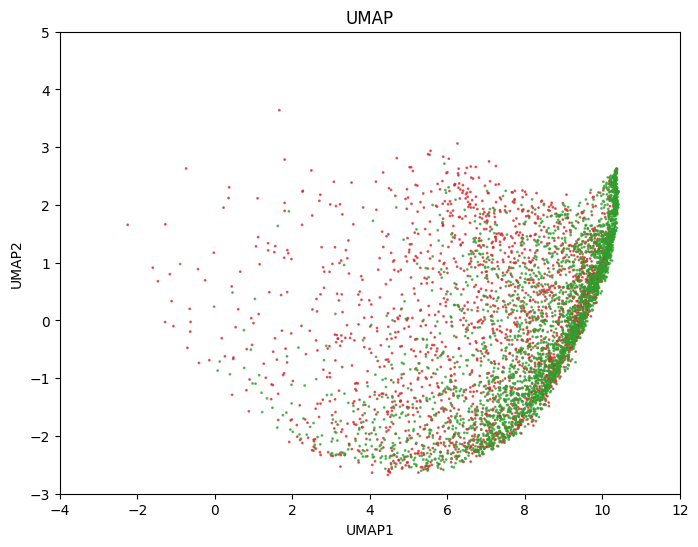

In [27]:
fig = umap_2Dplot(latents_lat8_2d, 0,1,1-patch_label_df['group_labels']+1)
plt.xlim([-4,12])
plt.ylim([-3,5])

In [16]:
csv_folder = analysis_base + 'ctrl_ch1_major/ctrl_ch1_patches_gridonly_wholecell_pslocation00/plot_patches32_65p_20251125_1159'

csv_filename = 'data_prep_record_9_t9.csv'
group_labels = 0
ctrl_y_str = 'ctrl'
seg_folder_str = 'code_org_20250902_seg'
cell_mask_folder = analysis_base+ctrl_y_str+'_ch1_major'+'/'+seg_folder_str+'/mask'

sub = 'Control' if ctrl_y_str == 'ctrl' else 'Y-comp'
image_folder = f"{czi_base}/{sub}"

model_min = 0
model_max = 52300
newdata_min = 9
newdata_max = 28700


In [17]:
print('make the latent and df')
matched_ctrl_patch_label_df, matched_ctrl_latent_array = patch_csv_to_AE_latent(ctrl_y_str,csv_folder,csv_filename,group_labels,model_min, model_max,newdata_min, newdata_max,ae, device)
joblib.dump(matched_ctrl_latent_array,os.path.join(output_rootdir, 'matched_trainvalcorrect_ctrl_latent_array.pkl'))
matched_ctrl_patch_label_df.to_csv(os.path.join(output_rootdir, 'matched_trainvalcorrect_ctrl_patch_label_df.csv'))

make the latent and df


In [18]:
csv_folder = analysis_base + 'y_ch1_major/y_ch1_patches_gridonly_wholecell_pslocation00/plot_patches32_65p_20251125_1139'
csv_filename = 'data_prep_record_10_t10.csv'
group_labels = 1
ctrl_y_str = 'y'
seg_folder_str = 'code_org_20250902_seg'
cell_mask_folder = analysis_base + ctrl_y_str+'_ch1_major'+'/'+seg_folder_str+'/mask'

sub = 'Control' if ctrl_y_str == 'ctrl' else 'Y-comp'
image_folder = f"{czi_base}/{sub}"


In [19]:
print('make the Y latent and df')
matched_y_patch_label_df, matched_y_latent_array = patch_csv_to_AE_latent(ctrl_y_str,csv_folder,csv_filename,group_labels,model_min, model_max,newdata_min, newdata_max,ae,device)
joblib.dump(y_latent_array,os.path.join(output_rootdir, 'matched_trainvalcorrect_y_latent_array.pkl'))
matched_y_patch_label_df.to_csv(os.path.join(output_rootdir, 'matched_trainvalcorrect_y_patch_label_df.csv'))

make the Y latent and df


In [20]:
matched_patch_label_df = pd.concat([matched_ctrl_patch_label_df, matched_y_patch_label_df], ignore_index=True)

# latent_array = np.concatenate([ctrl_latent_array_np_plus6, y_latent_array_np_plus6])
matched_latent_array = np.concatenate([matched_ctrl_latent_array, matched_y_latent_array])

print(matched_latent_array.shape)

(5251, 8)


In [ ]:
matched_latents_lat8_2d = latent_to_umap(os.path.join(root_dir,'vindata_pax_AE_wholecell_lat8_UMAP.pkl'), matched_latent_array[:,:8])



In [ ]:
matched_latent_array

(-3.0, 5.0)

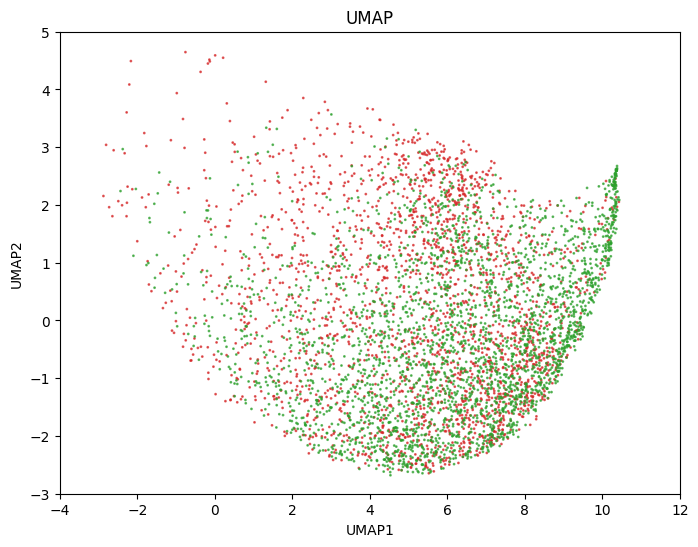

In [26]:
fig = umap_2Dplot(matched_latents_lat8_2d, 0,1,1-patch_label_df['group_labels']+1)
plt.xlim([-4,12])
plt.ylim([-3,5])